In [1]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver #ram main memory store karta

In [2]:
llm = ChatGroq(
    model='openai/gpt-oss-120b'
)

In [3]:
llm.invoke("hi").content

'Hello! How can I assist you today?'

In [4]:
class JokeStatef(TypedDict):


    topic: str
    joke: str
    explanation: str
    

In [5]:
def generate_joke(state: JokeStatef):
    prompt = f'generate a joke on the topic {state['topic']}'

    response = llm.invoke(prompt).content

    return {'joke': response}

In [6]:
def generate_explanation(state: JokeStatef):
    prompt = f'write an explanation for the joke - {state['joke']}'

    response = llm.invoke(prompt).content

    return {'explanation': response}

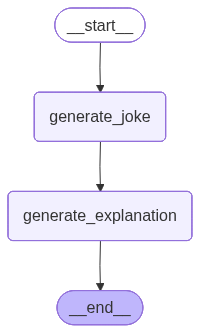

In [7]:
graph = StateGraph(JokeStatef)


graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer)


workflow

In [8]:
from IPython.display import Markdown , display

In [9]:
config1= {"configurable":{"thread_id":"1"}}

reply =workflow.invoke({'topic': 'pizza'},config1)

display(Markdown(reply['joke']))

Why did the pizza apply for a job?

Because it wanted to *deliver* on its crust‑tastic résumé! 🍕😄

In [10]:
display(Markdown(reply['explanation']))

**Why the joke works – a step‑by‑step breakdown**

| Element of the joke | What it normally means | The pun / wordplay | Why it’s funny |
|---------------------|------------------------|--------------------|----------------|
| **“Why did the pizza apply for a job?”** | Sets up a classic “knock‑knock/why‑did‑the‑chicken” style riddle. The listener expects a mundane answer about a pizza’s “career.” | The idea of a **food item** looking for employment is already absurd, creating a playful mental image. | The absurdity primes the audience for a goofy punch‑line. |
| **“Because it wanted to *deliver* on its crust‑tastic résumé!”** | • **Deliver** – in a job context, “to deliver” means to fulfill promises or meet expectations.<br>• **Résumé** – a document listing one’s qualifications for a job. | 1. **Deliver** also refers to pizza delivery, the most common way we get pizza.<br>2. **Crust‑tastic** blends “crust” (the pizza’s outer edge) with “fantastic,” turning a culinary term into a bragging adjective.<br>3. The phrase “deliver on its résumé” mixes the job‑search idiom with the literal act of delivering pizza. | The humor comes from **layered wordplay**:<br>• The double meaning of *deliver* (perform well vs. physically bring pizza).<br>• The made‑up adjective *crust‑tastic* mimics how people hype their own skills on a résumé, but with a pizza‑specific twist.<br>• The mental image of a slice of pizza polishing a résumé and heading to an interview is delightfully ridiculous. |

### The comedic mechanisms at play

1. **Pun/Double Meaning**  
   - *Deliver* works on two levels (job performance and pizza delivery). Puns that hinge on a single word with two unrelated meanings are a classic source of light‑hearted humor.

2. **Portmanteau / Word‑blend**  
   - *Crust‑tastic* is a portmanteau of “crust” + “fantastic.” The unexpected mash‑up sounds like a confident brag you might read on a résumé, but it’s anchored in pizza terminology.

3. **Absurdity & Personification**  
   - Giving a pizza human goals (getting a job, polishing a résumé) is a form of personification. The sheer silliness of a pizza caring about its “career prospects” makes the line funny.

4. **Expectation Subversion**  
   - The setup leads us to anticipate a simple punch‑line about pizza toppings or delivery. Instead we get a meta‑joke about job‑application language, catching the listener off guard.

5. **Emoji Reinforcement**  
   - The 🍕 and 😄 emojis cue the reader that the tone is playful, reinforcing that the joke is meant to be light‑hearted rather than a serious riddle.

### Putting it all together

The joke works because it **marries two worlds**—the culinary world of pizza and the professional world of job hunting—through a clever double‑meaning word (*deliver*) and a whimsical adjective (*crust‑tastic*). The mental image of a pizza polishing its résumé and heading off to “deliver” on its promises is both **unexpected** and **delightfully ridiculous**, which is exactly what makes a punny joke land.

In [11]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to *deliver* on its crust‑tastic résumé! 🍕😄', 'explanation': '**Why the joke works – a step‑by‑step breakdown**\n\n| Element of the joke | What it normally means | The pun / wordplay | Why it’s funny |\n|---------------------|------------------------|--------------------|----------------|\n| **“Why did the pizza apply for a job?”** | Sets up a classic “knock‑knock/why‑did‑the‑chicken” style riddle. The listener expects a mundane answer about a pizza’s “career.” | The idea of a **food item** looking for employment is already absurd, creating a playful mental image. | The absurdity primes the audience for a goofy punch‑line. |\n| **“Because it wanted to *deliver* on its crust‑tastic résumé!”** | • **Deliver** – in a job context, “to deliver” means to fulfill promises or meet expectations.<br>• **Résumé** – a document listing one’s qualifications for a job. | 1. **Deliver** also refers

In [12]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to *deliver* on its crust‑tastic résumé! 🍕😄', 'explanation': '**Why the joke works – a step‑by‑step breakdown**\n\n| Element of the joke | What it normally means | The pun / wordplay | Why it’s funny |\n|---------------------|------------------------|--------------------|----------------|\n| **“Why did the pizza apply for a job?”** | Sets up a classic “knock‑knock/why‑did‑the‑chicken” style riddle. The listener expects a mundane answer about a pizza’s “career.” | The idea of a **food item** looking for employment is already absurd, creating a playful mental image. | The absurdity primes the audience for a goofy punch‑line. |\n| **“Because it wanted to *deliver* on its crust‑tastic résumé!”** | • **Deliver** – in a job context, “to deliver” means to fulfill promises or meet expectations.<br>• **Résumé** – a document listing one’s qualifications for a job. | 1. **Deliver** also refer

In [13]:
config2= {"configurable":{"thread_id":"2"}}

reply =workflow.invoke({'topic': 'ants'},config2)

display(Markdown(reply['joke']))

Why did the ant bring a ladder to the picnic?  

Because it heard the food was *high* in protein and wanted to get a *step* ahead!

In [14]:
from langchain_core.runnables import config
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'ants', 'joke': 'Why did the ant bring a ladder to the picnic?  \n\nBecause it heard the food was *high* in protein and wanted to get a *step* ahead!', 'explanation': '**Explanation of the Joke**\n\n> **Setup:** “Why did the ant bring a ladder to the picnic?”  \n> **Punchline:** “Because it heard the food was *high* in protein and wanted to get a *step* ahead!”\n\n---\n\n### 1. The literal picture\n- **Ant:** A tiny insect that, in reality, could never climb a ladder the way a human does.  \n- **Ladder:** A tool used to reach something that is physically higher than you can reach on your own.  \n- **Picnic:** A casual outdoor meal where food is laid out on a blanket or table, usually at ground level.\n\nIf you take the scenario at face value, the image is absurd: a minuscule ant hauling a comparatively huge ladder to a ground‑level spread of food. The absurdity itself hints that the joke is going to rely on wordplay rather than a realistic situation.\n\n

In [15]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'ants', 'joke': 'Why did the ant bring a ladder to the picnic?  \n\nBecause it heard the food was *high* in protein and wanted to get a *step* ahead!', 'explanation': '**Explanation of the Joke**\n\n> **Setup:** “Why did the ant bring a ladder to the picnic?”  \n> **Punchline:** “Because it heard the food was *high* in protein and wanted to get a *step* ahead!”\n\n---\n\n### 1. The literal picture\n- **Ant:** A tiny insect that, in reality, could never climb a ladder the way a human does.  \n- **Ladder:** A tool used to reach something that is physically higher than you can reach on your own.  \n- **Picnic:** A casual outdoor meal where food is laid out on a blanket or table, usually at ground level.\n\nIf you take the scenario at face value, the image is absurd: a minuscule ant hauling a comparatively huge ladder to a ground‑level spread of food. The absurdity itself hints that the joke is going to rely on wordplay rather than a realistic situation.\n\n-

## Fault Tolerance



In [16]:


from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time



In [17]:
class Crash_state(TypedDict):
    input : str
    step1: str
    step2: str
    

In [18]:
def step_1(state: Crash_state) -> Crash_state:
     print("✅ Step 1 executed")
     return {"step1": "done", "input": state["input"]}
def step_2(state: Crash_state) -> Crash_state:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: Crash_state) -> Crash_state:
    print("✅ Step 3 executed")
    return {"done": True}

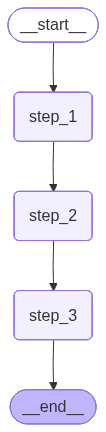

In [19]:


# 3. Build the graph
builder = StateGraph(Crash_state)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

graph


In [20]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [21]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))



[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17a840-6569-6ab6-8001-2c678b07e390'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-08T04:18:08.580620+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17a840-6564-61d5-8000-668fd30599ae'}}, tasks=(PregelTask(id='e7b0b870-e156-537f-2752-22f228bb0855', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17a840-6564-61d5-8000-668fd30599ae'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-08T04:18:08.578361+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch

In [22]:
graph.get_state({"configurable":{"thread_id":"thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17a840-6569-6ab6-8001-2c678b07e390'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-08T04:18:08.580620+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17a840-6564-61d5-8000-668fd30599ae'}}, tasks=(PregelTask(id='e7b0b870-e156-537f-2752-22f228bb0855', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [23]:

# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)




🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [24]:
graph.get_state({"configurable":{"thread_id":"thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17a842-0998-6f20-8003-48e735f48d3e'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07-08T04:18:52.640206+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17a842-0995-634d-8002-caa07e1b34e3'}}, tasks=(), interrupts=())

In [34]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa apply for a job?  \n\nBecause it heard the position was “filled” with “crunchy” responsibilities and it wanted to show it could handle the “stuffing” of any task!', 'explanation': '**Joke:**  \n*Why did the samosa apply for a job?*  \n*Because it heard the position was “filled” with “crunchy” responsibilities and it wanted to show it could handle the “stuffing” of any task!*\n\n---\n\n## Why it’s funny – a step‑by‑step breakdown  \n\n| Part of the punchline | Literal meaning (job‑world) | Food‑related meaning (samosa) | How the two meanings collide |\n|-----------------------|-----------------------------|-------------------------------|------------------------------|\n| **“filled”** | A job that is *full* of duties, tasks, or responsibilities. | A samosa is *filled* with a mixture of potatoes, peas, spices, etc. | The word “filled” works both for a busy job and for the interior of a samosa. |\n| **“crunchy”** | Desc

In [26]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f17a840-2f99-6c04-8000-73e177634e65"}})



StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f17a840-2f99-6c04-8000-73e177634e65'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-08T04:18:02.938020+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17a840-2f92-6e75-bfff-eedef3067468'}}, tasks=(PregelTask(id='9d1d6ba3-f5ca-6d83-1508-dea92b02795e', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to *deliver* on its crust‑tastic résumé! 🍕😄'}),), interrupts=())

In [27]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f17a840-2f99-6c04-8000-73e177634e65"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for “dough‑main” expertise and it wanted a slice of the action! 🍕😄',
 'explanation': '**Breaking Down the Joke**\n\n| Part of the joke | What it literally means | The wordplay / pun |\n|------------------|------------------------|--------------------|\n| **“Why did the pizza apply for a job?”** | Sets up a classic “why did X do Y?” riddle format. The expectation is a funny, unexpected reason. | The humor will come from treating a pizza—a food item—as if it were a person looking for employment. |\n| **“Because it heard the company was looking for ‘dough‑main’ expertise”** | • “Dough” is the raw mixture of flour, water, yeast, etc., that becomes pizza crust.<br>• “Domain expertise” is a business‑speak phrase meaning deep knowledge in a particular area. | The joke swaps **domain** with **dough‑main**. By inserting “dough” (the pizza’s main ingredient) into the phrase, it creates a p

In [29]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f17a840-2f99-6c04-8000-73e177634e65", "checkpoint_ns": ""}}, {'topic':'samosa'})



{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17a857-8ca2-6af1-8001-23014c65c2fb'}}

In [32]:
list(workflow.get_state_history(config1))


[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?  \n\nBecause it heard the company was looking for someone who could *deliver* under pressure and really *roll* with the dough! 🍕😄', 'explanation': '**Joke:**  \n*Why did the pizza apply for a job?*  \n*Because it heard the company was looking for someone who could **deliver** under pressure and really **roll** with the dough! 🍕😄*\n\n---\n\n### Why it’s funny – a step‑by‑step breakdown  \n\n| Phrase in the punchline | What it means in everyday work‑place lingo | What it means for a pizza (the literal, food‑related sense) | Why the clash is amusing |\n|--------------------------|--------------------------------------------|-----------------------------------------------------------|---------------------------|\n| **“deliver”** | To complete tasks, meet deadlines, and hand over results to clients or a boss. | A pizza is *delivered* to a customer’s door (or to a table). | The word is used in both the corpo

In [33]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f17a857-8ca2-6af1-8001-23014c65c2fb"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa apply for a job?  \n\nBecause it heard the position was “filled” with “crunchy” responsibilities and it wanted to show it could handle the “stuffing” of any task!',
 'explanation': '**Joke:**  \n*Why did the samosa apply for a job?*  \n*Because it heard the position was “filled” with “crunchy” responsibilities and it wanted to show it could handle the “stuffing” of any task!*\n\n---\n\n## Why it’s funny – a step‑by‑step breakdown  \n\n| Part of the punchline | Literal meaning (job‑world) | Food‑related meaning (samosa) | How the two meanings collide |\n|-----------------------|-----------------------------|-------------------------------|------------------------------|\n| **“filled”** | A job that is *full* of duties, tasks, or responsibilities. | A samosa is *filled* with a mixture of potatoes, peas, spices, etc. | The word “filled” works both for a busy job and for the interior of a samosa. |\n| **“crunchy”** | Describes work that is *